# Data Check & EDA

## Mount Google Drive

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Unzip Dataset

In [78]:
!unzip -o -q "/content/drive/MyDrive/Dataset/garbage_classification/archive.zip" -d "./garbage_classification"
!ls ./garbage_classification

'garbage classification'	       one-indexed-files-notrash_val.txt
'Garbage classification'	       one-indexed-files.txt
 one-indexed-files-notrash_test.txt    zero-indexed-files.txt
 one-indexed-files-notrash_train.txt


## Set Dataset Path

In [79]:
import os

dataset_path = "./garbage_classification/Garbage classification/Garbage classification"

classes = [cls for cls in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, cls))]
print("Final Classes:", classes)

Final Classes: ['metal', 'glass', 'cardboard', 'trash', 'paper', 'plastic']


## Count Images per Class

In [80]:
class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}
print("Image counts per class:", class_counts)

Image counts per class: {'metal': 410, 'glass': 501, 'cardboard': 403, 'trash': 137, 'paper': 594, 'plastic': 482}


## Visualize Class Distribution

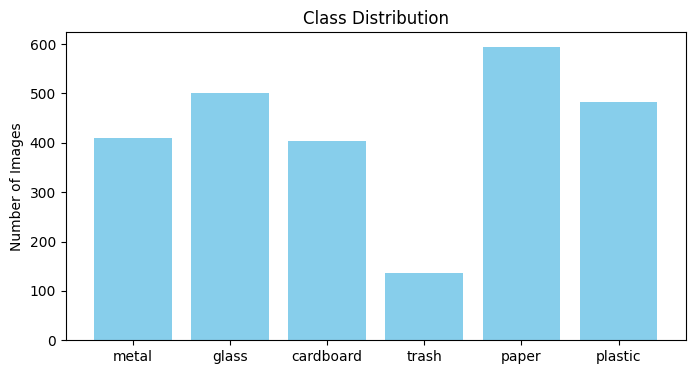

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

## Show Sample Images

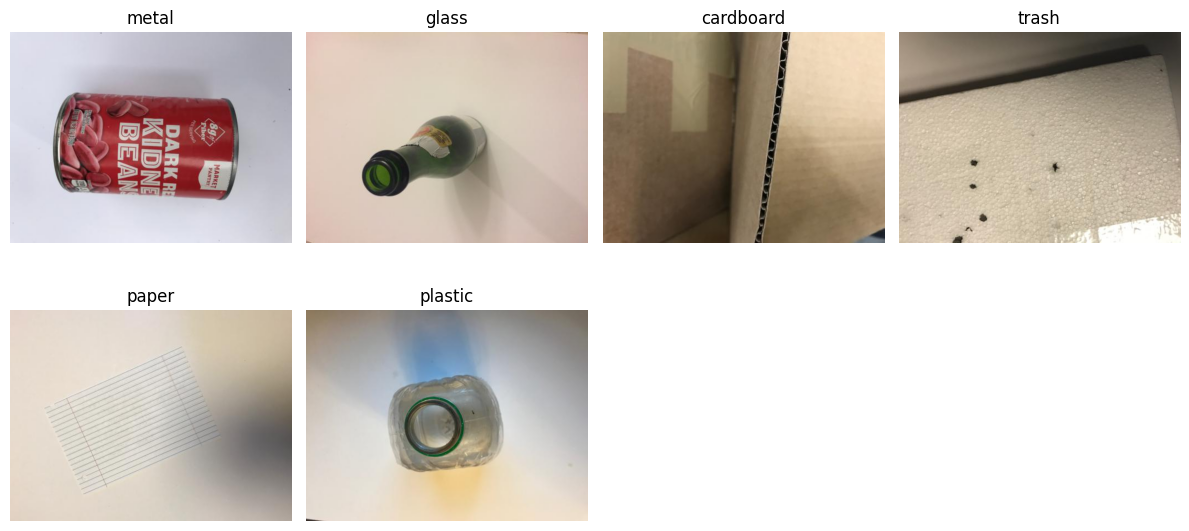

In [82]:
import cv2

plt.figure(figsize=(12,6))
for idx, cls in enumerate(classes):
    img_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])
    img = cv2.imread(img_path)[:,:,::-1]  # BGR → RGB
    plt.subplot(2, len(classes)//2 + 1, idx+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

##  Train/Validation Split + Data Loader

In [83]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Import Libraries

In [84]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define CNN Model

In [85]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_13 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [86]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [87]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.2538 - loss: 2.0773 - val_accuracy: 0.4356 - val_loss: 1.3726
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.4663 - loss: 1.3352 - val_accuracy: 0.3901 - val_loss: 1.4162
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.5103 - loss: 1.2289 - val_accuracy: 0.4832 - val_loss: 1.2851
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.5965 - loss: 1.0389 - val_accuracy: 0.5287 - val_loss: 1.1791
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.6771 - loss: 0.8657 - val_accuracy: 0.5168 - val_loss: 1.2814
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.7486 - loss: 0.7152 - val_accuracy: 0.5149 - val_loss: 1.5359
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7950 - loss: 0.5756 - val_accuracy: 0.5802 - val_loss: 1.2154
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8666 - loss: 0.3944 - val_accuracy: 0.5762 

## Plot Training Results

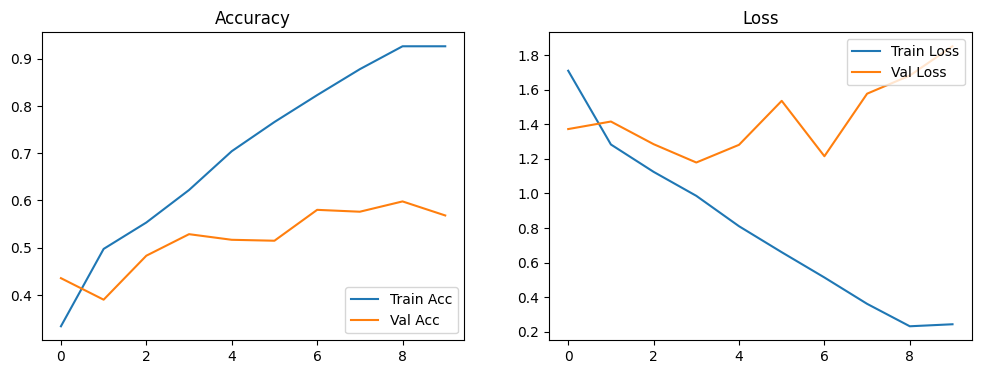

In [88]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()

# Transfer Learning with MobileNetV2

## Data Augmentation


In [89]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

## Build Model (MobileNetV2 backbone)

In [90]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

backbone = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
backbone.trainable = False

num_classes = len(class_names)

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_15 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_14 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile & Train

In [91]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

class_weight = {
    0: 1.0,
    1: 1.0,
    2: 1.0,
    3: 1.0,
    4: 1.0,
    5: 1.5
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
    ]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.1833 - loss: 2.4331 - val_accuracy: 0.2436 - val_loss: 1.8191 - learning_rate: 1.0000e-04
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.2264 - loss: 2.1231 - val_accuracy: 0.3624 - val_loss: 1.5806 - learning_rate: 1.0000e-04
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3084 - loss: 1.8857 - val_accuracy: 0.4554 - val_loss: 1.4094 - learning_rate: 1.0000e-04
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3246 - loss: 1.8068 - val_accuracy: 0.5089 - val_loss: 1.2763 - learning_rate: 1.0000e-04
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.4199 - loss: 1.5852 - val_accuracy: 0.5564 - val_loss: 1.1797 - learning_rate: 1.0000e-04
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4595 - loss: 1.4444 - val_accuracy: 0.5881 - val_loss: 1.1042 - learning_rate: 1.0000e-04
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.511

## Fine-Tuning

In [92]:
backbone.trainable = True
fine_tune_at = len(backbone.layers) - 40
for layer in backbone.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
    ]
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.4532 - loss: 1.5437 - val_accuracy: 0.6931 - val_loss: 0.8689 - learning_rate: 1.0000e-05
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.5302 - loss: 1.3440 - val_accuracy: 0.7050 - val_loss: 0.8358 - learning_rate: 1.0000e-05
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.5954 - loss: 1.1440 - val_accuracy: 0.7208 - val_loss: 0.8130 - learning_rate: 1.0000e-05
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6289 - loss: 1.0478 - val_accuracy: 0.7109 - val_loss: 0.8024 - learning_rate: 1.0000e-05
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.6627 - loss: 0.9971 - val_accuracy: 0.7149 - val_loss: 0.7720 - learning_rate: 1.0000e-05
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.6875 - loss: 0.8668 - val_accuracy: 0.7208 - val_loss: 0.7516 - learning_rate: 1.0000e-05
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 

In [93]:
model.save("garbage_classifier.h5")

## Confusion Matrix

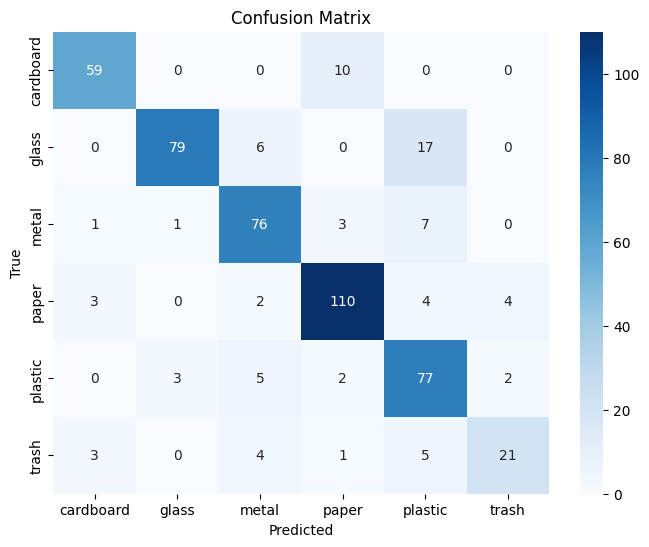

              precision    recall  f1-score   support

   cardboard     0.8939    0.8551    0.8741        69
       glass     0.9518    0.7745    0.8541       102
       metal     0.8172    0.8636    0.8398        88
       paper     0.8730    0.8943    0.8835       123
     plastic     0.7000    0.8652    0.7739        89
       trash     0.7778    0.6176    0.6885        34

    accuracy                         0.8356       505
   macro avg     0.8356    0.8117    0.8190       505
weighted avg     0.8452    0.8356    0.8362       505



In [94]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true, y_pred = np.array(y_true), np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_ds.class_names,
            yticklabels=val_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=val_ds.class_names, digits=4))

## Baseline vs Transfer

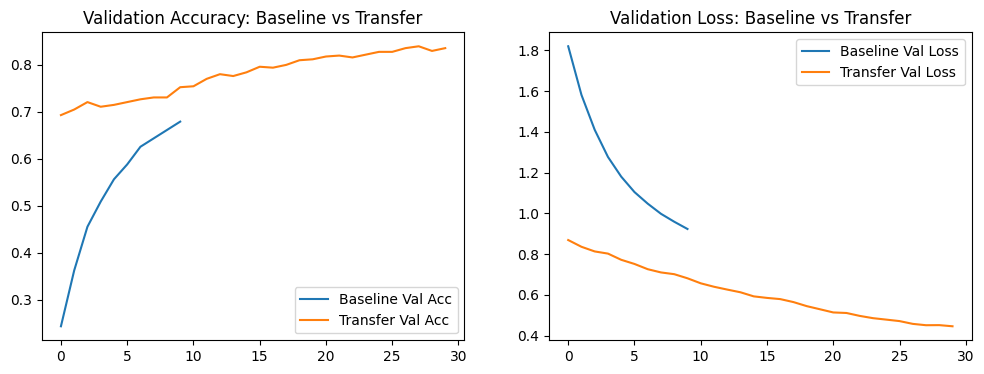

In [95]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='Baseline Val Acc')
plt.plot(fine_history.history['val_accuracy'], label='Transfer Val Acc')
plt.legend()
plt.title("Validation Accuracy: Baseline vs Transfer")

plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='Baseline Val Loss')
plt.plot(fine_history.history['val_loss'], label='Transfer Val Loss')
plt.legend()
plt.title("Validation Loss: Baseline vs Transfer")

plt.show()